## Aligning PACE and EMIT Data

Authors: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 04/29/2026

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[emit-data-access]: https://nasa.github.io/VITALS/python/Exploring_EMIT_L2A_RFL.html
[help-hub]: https://nasa.github.io/oceandata-notebooks/
[vitals]: https://nasa.github.io/VITALS/

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA PACE and EMIT data.

</div>

## Summary
The Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) mission and the Earth Surface Mineral Dust Source Investigation (EMIT) sensor aboard the International Space Station (ISS) both make hyperspectral observations of the Earth's surface. Taking into account their different spectral, spatial, and temporal coverage, these instruments' capabilities are extremely complementary and provide a wealth of new opportunities when used in concert. In this series of tutorials, we will demonstrate how to find, prepare, and use data from both PACE and EMIT together, illustarting each missions' strengths and where they can fill in each others' gaps.

This is the second tutorial in the PACE-EMIT series. This notebook will use the reflectance data downloaded from the first tutorial, `01_Colocate_PACE_EMIT_data`, as well as the `rasterio` and `rioxarray` packages to put PACE Ocean Color Instrument (OCI) and EMIT data on the same grid. We will use tools from LPDAAC's VITALS tutorials to orthorectify the EMIT data, and then place PACE and EMIT granules on a generalized grid using OCI's coarser resolution. We can then compare the data from the two sensors. These techniques will also be integral to our fire analyses in the third tutorial, `03_NBR_with_PACE_EMIT`.

## Learning Objectives

At the end of this notebook, you will know how to:
- Open and orthorectify an EMIT granule
- Open a PACE OCI granule and take it from swath to a defined grid
- Upscale PACE OCI to EMIT resolution

## Contents
1. [Setup](#1.-Setup)
2. [Preprocessing Instrument Data](#2.-Preprocessing-Instrument-Data)
3. [Spectral Comparisons](#3.-Spectral-Comparisons)
4. [Grid Alignment](#4.-Grid-Alignment)


## 1. Setup

Begin by importing all of the packages used in this notebook.

In [1]:
import os
import glob
import cartopy
import rasterio 
import cf_xarray 
import numpy as np 
import xarray as xr 
import rioxarray as rio
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 
import geopandas as gpd
import earthaccess
import skimage
import pandas as pd
from pathlib import Path
from rasterio.crs import CRS
from rasterio.enums import Resampling
from mpl_toolkits.axes_grid1 import make_axes_locatable

os.chdir(os.path.abspath(os.path.join(get_ipython().starting_dir, os.pardir)))
from modules import pace_tools as pace
from modules import emit_tools as emit
from modules.ewt_calc import calc_ewt

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)


def plot_features(ax, gridline_alpha=1):
    """
    Function to add gridlines and cartopy features to a figure.
    Args:
        ax - matplotlib Axes object on which to plot the features
        gridline_alpha - fractional opacity of gridlines on the plot. Will also 
             make sure x, y axes are labelled with lon/lats, respectively. 0 will 
             include axes labels but not plot gridlines
    """
    for a in range(len(ax)):
        ax[a].gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=gridline_alpha)
        ax[a].coastlines(linewidth=0.5)
        ax[a].add_feature(cartopy.feature.OCEAN, edgecolor="w", linewidth=0.01)
        ax[a].add_feature(cartopy.feature.LAND, edgecolor="w", linewidth=0.01)
        ax[a].add_feature(cartopy.feature.LAKES, edgecolor="w", linewidth=0.01)

# Set Up Extents with GDF
gdf_bbox = gpd.read_file("emit_pace/data/grampians_bbox.geojson")

In the last notebook, we found and downloaded EMIT and PACE data corresponding to one pre-fire and one post-fire day for the Grampians National Park fire in Victoria, Australia, as one of our eventual goals for the third tutorial notebook is to compute the difference in Normalized Burn Ratio (dNBR) with both of our instruments. 

We'll be using these files for the rest of the tutorials in this series, and so define their paths for this notebook in the cell below. Please change these paths to your own download locations if it differs from those below. 

In [2]:
emit_paths = sorted(glob.glob("emit_pace/data/EMIT_L2A*.nc"))
oci_paths = sorted(glob.glob("emit_pace/data/PACE_OCI*.nc"))
oci_ts_paths = sorted(glob.glob("emit_pace/ts_data/PACE_OCI*.nc"))

# Make into path objs 
emit_paths = [Path(i) for i in emit_paths]
oci_paths = [Path(i) for i in oci_paths]
oci_ts_paths = [Path(i) for i in oci_ts_paths]

If for some reason you need to download these files, uncomment and run the cell below.

In [3]:
# Download Data
#emit_urls = ["https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035759_2431902_009/EMIT_L2A_RFL_001_20241114T035759_2431902_009.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035759_2431902_009/EMIT_L2A_MASK_001_20241114T035759_2431902_009.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20241114T035747_2431902_008/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022818_2507801_008/EMIT_L2A_MASK_001_20250319T022818_2507801_008.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022830_2507801_009/EMIT_L2A_RFL_001_20250319T022830_2507801_009.nc",
#             "https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250319T022830_2507801_009/EMIT_L2A_MASK_001_20250319T022830_2507801_009.nc"
#             ]
# NOTE: These aren't all the same pace urls as i have downloaded now
#pace_urls = ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241218T202231.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250113T204049.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250212T032254.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250224T035613.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250301T033714.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250304T034526.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250305T042058.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250307T035339.L2.SFREFL.V3_1.nc',
#             'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250313T041003.L2.SFREFL.V3_1.nc'
#            ]
#
#earthaccess.login()
#emit_paths = earthaccess.download(emit_urls, "emit_pace/data/downloaded")
#oci_paths = earthaccess.download(pace_urls, "emit_pace/data/downloaded")

Recall from the previous tutorial that these are Level-2 (L2) data. An important aspect of L2 data from most sensors is that that they are still in the instrument swath, meaning they are not on any predefined grid. Comparing the raw datasets, even doing so with two granules from the same sensor, would be inaccurate because the pixels do not represent the same location on the Earth. Especially because the eventual goal of this tutorial series is to compare data between sensors, we need to make sure our pixel centers have the same latitudes and longitudes - in other words, we have to grid our data.

To accomplish this gridding, we have to treat EMIT and PACE OCI data slightly differently. The EMIT L2A reflectance file comes with a geometry lookup table (GLT) in addition to the latitude and longitude of each pixel, which allows us to reproject the raw EMIT data onto a geographic grid. L2 Data from PACE does not have a GLT, so we will have to use another technique to project the data. 

### 2. Preprocessing Instrument Data

### EMIT Data

The [VITALS][vitals] repository provides the `emit_tools` module which includes several functions to ease working with EMIT data. We'll use these first to orthorectify those data. More information can be found in the [EMIT-Data-Resources repository](https://github.com/nasa/EMIT-Data-Resources)

[vitals]: https://nasa.github.io/VITALS/

The `emit_xarray` function in the `emit_tools` module is what will allow us to grid EMIT data. The `ortho=True` argument in the cell below tells the function to use the GLT to orthorectify the specific scenes we feed it. Recall also that we needed two EMIT scenes to cover the full extent of our region of interest (ROI). The `emit_tools` module also includes functions to merge granules in order to create one cohesive dataset. The `process_and_merge_emit` function below will combine all of these steps and so we can efficiently preprocess our data.

In [4]:
# EMIT - Open, Spatial Subset, Mask, Ortho
def process_and_merge_emit(rfl_paths, mask_paths, polygon_path, mask_bands, outdir):
    """Preprocess a list of EMIT RFL+MASK pairs and write a single merged NetCDF."""
    out_path = outdir / f"{rfl_paths[0].stem}_ortho_merged.nc"
    if out_path.exists():
        print("Output already exists!")
        return out_path
    gdf = gpd.read_file(polygon_path)

    scenes = []
    for rfl_path, mask_path in zip(rfl_paths, mask_paths):
        rfl  = emit.emit_xarray(rfl_path)
        mask = (emit.emit_xarray(mask_path)["mask"]
                    .sel(mask_bands=mask_bands).any("mask_bands").astype(int))
        rfl  = rfl.where(mask == 0)
        rfl  = emit.spatial_subset(rfl, gdf)
        scenes.append(emit.ortho_xr(rfl))

    merged = emit.merge_emit(scenes, gdf)
    
    merged.to_netcdf(out_path)
    return out_path

In [5]:
# Already sorted
emit_paths

[PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20241114T035759_2431902_009.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20250319T022818_2507801_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_MASK_001_20250319T022830_2507801_009.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20241114T035759_2431902_009.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc'),
 PosixPath('emit_pace/data/EMIT_L2A_RFL_001_20250319T022830_2507801_009.nc')]

In [6]:
# Set up args for preproc fcn
OUTDIR = Path.cwd() / "emit_pace" / "data" / "outputs"
gdf_path = "emit_pace/data/grampians_bbox.geojson"
mask_bands = ['Cloud flag','Cirrus flag','Water flag','Spacecraft Flag']

note that the following cell will take 

reword but explain fcn 

EMIT data also comes with a quaity mask in a separate file, which we will apply to the data. These also have to be orthorectified, and we can use the same function as above. Once we have the mask data, we can see which flags are provided in the mask. 

In [7]:
# Preprocess and Merge Scene Pairs
prefire_emit_path = process_and_merge_emit(rfl_paths=emit_paths[4:6],
                                            mask_paths=emit_paths[0:2],
                                            polygon_path=gdf_path,
                                            mask_bands=mask_bands,
                                            outdir=OUTDIR)
postfire_emit_path = process_and_merge_emit(rfl_paths=emit_paths[6:8],
                                             mask_paths=emit_paths[2:4],
                                             polygon_path=gdf_path,
                                             mask_bands=mask_bands,
                                             outdir=OUTDIR)



Output already exists!
Output already exists!


In [8]:
# Open merged EMIT files
prefire_emit_ds = xr.open_dataset(prefire_emit_path)
postfire_emit_ds = xr.open_dataset(postfire_emit_path)

In [9]:
prefire_emit_ds

<xarray.Dataset> Size: 2GB
Dimensions:           (latitude: 1420, longitude: 931, wavelengths: 285)
Coordinates:
  * latitude          (latitude) float64 11kB -36.87 -36.87 ... -37.64 -37.64
  * longitude         (longitude) float64 7kB 142.2 142.2 142.2 ... 142.7 142.7
    elev              (latitude, longitude) float32 5MB ...
  * wavelengths       (wavelengths) float32 1kB 381.0 388.4 ... 2.493e+03
    good_wavelengths  (wavelengths) float32 1kB ...
    fwhm              (wavelengths) float32 1kB ...
Data variables:
    reflectance       (latitude, longitude, wavelengths) float32 2GB ...
    spatial_ref       int64 8B ...
Attributes: (12/41)
    ncei_template_version:             NCEI_NetCDF_Swath_Template_v2.0
    summary:                           The Earth Surface Mineral Dust Source ...
    keywords:                          Imaging Spectroscopy, minerals, EMIT, ...
    Conventions:                       CF-1.63
    sensor:                            EMIT (Earth Surface Mineral Dust Sourc...
    instrument:                        EMIT
    ...                                ...
    geotransform:                      [ 1.42180140e+02  5.42232520e-04  0.00...
    day_night_flag:                    Day
    title:                             EMIT L2A Estimated Surface Reflectance...
    granule_id:                        EMIT_L2A_RFL_001_20241114T035747_24319...
    subset_downtrack_range:            [ 388 1279]
    subset_crosstrack_range:           [   0 1232]

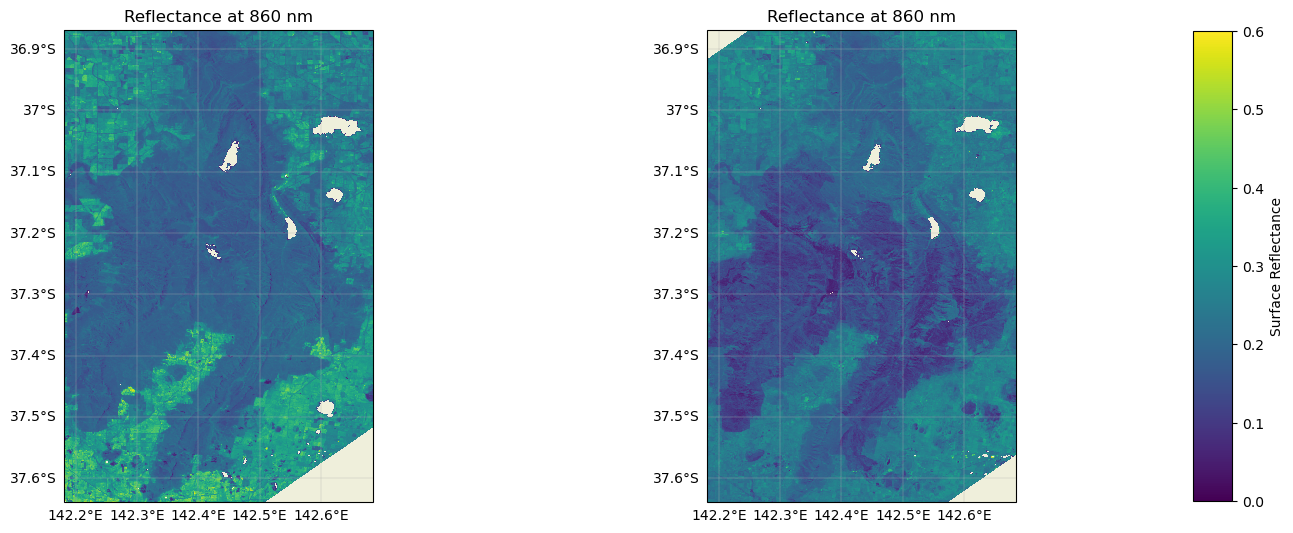

In [10]:
# Plot
fig, ax = plt.subplots(1,2, figsize=(13,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=1)
im = prefire_emit_ds["reflectance"].sel(wavelengths=860, 
                                 method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6,
                                                        add_colorbar=False)
postfire_emit_ds["reflectance"].sel(wavelengths=860, 
                             method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, 
                                                    add_colorbar=False)

plot_features(ax.flatten())
bbox = [141.9385, -37.74163, 142.77324, -36.79961]

cax = fig.add_axes([1.0025, 0.03, 0.03, 0.94]) 
fig.colorbar(im, cax=cax, label="Surface Reflectance")

# TODO: Replace with ntl park boundary?
# Plot bbox as a closed polygon
#ax[0].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
#           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
#           color='red', linewidth=2, transform=ccrs.PlateCarree())
#ax[1].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
#           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
#           color='red', linewidth=2, transform=ccrs.PlateCarree())

ax[0].set_title("Reflectance at 860 nm")
ax[1].set_title("Reflectance at 860 nm")   

plt.show()

Our EMIT data now match up to a physical location in space for each day of data, and moreover we have a full view of our ROI in one dataset. These observations can now be used together in calculations later on. Let's make sure the same is true for PACE. 

### PACE Data
The `pace_tools` module provides a suite of functions for working with PACE OCI data, similar to the `emit_tools` module. We'll use the `open_l2` and `mask_ds` functions to accomplish the same steps for PACE as we did above with EMIT, with the key difference that the PACE data will not be gridded directly after opening the file. The PACE data again do not include a GLT, and so we will use their included 2D `latitude` and `longitude` arrays to perform the gridding. The `process_pace` function will take our PACE data and preprocess it similarly to the EMIT data above, subsetting, masking, and gridding it so we can work with it later. 

In [11]:
# PACE - Open, Mask, Grid, Spatial Subset
def process_pace(pace_path, resolution, bbox, outdir):
    out_path = outdir / f"{pace_path.stem}_ortho_subset.nc"
    if out_path.exists():
        print("Output already exists!")
        return out_path
    ds = pace.open_l2(pace_path)
    ds = pace.mask_ds(ds, flag=["CLDICE","LAND"], reverse=[False,True])
    ds = pace.grid_data(ds, resolution=resolution)
    ds_sub = ds.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
    ds_sub.to_netcdf(out_path)
    return out_path

resolution = (0.015,0.015)
pace_subsets = [process_pace(oci_path, resolution, gdf_bbox.total_bounds, OUTDIR) for oci_path in oci_paths]
pace_ts_subsets = [process_pace(oci_path, resolution, gdf_bbox.total_bounds, OUTDIR) for oci_path in oci_ts_paths]
pace_ts_subsets

Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!
Output already exists!


[PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20241215T033822.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20250101T033916.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20250118T033938.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20250122T041511.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20250205T040925.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20250211T042542.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/python/emit_pace/data/outputs/PACE_OCI.20250212T032254.L2.SFREFL.V3_1_ortho_subset.nc'),
 PosixPath('/accounts/sacaplan/projects/VITALS/p

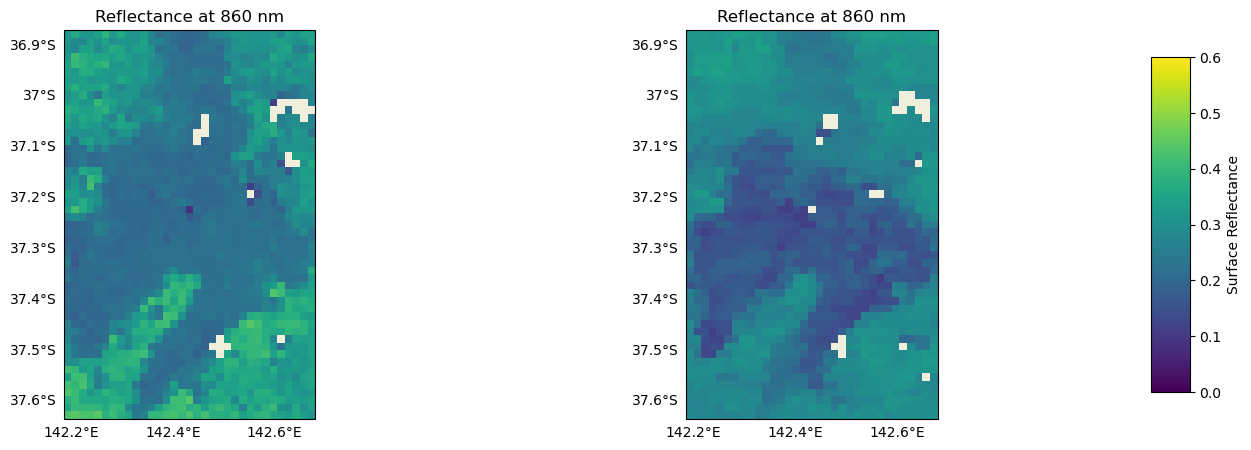

In [12]:
# open
prefire_oci_ds = xr.open_dataset(pace_subsets[0])
postfire_oci_ds = xr.open_dataset(pace_subsets[1])

# Plot
fig, ax = plt.subplots(1,2, figsize=(13,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=4)
prefire_oci_ds["rhos"].sel(wavelength_3d=860, 
                    method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6, add_colorbar=False)
im = postfire_oci_ds["rhos"].sel(wavelength_3d=860, 
                          method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, add_colorbar=False)

plot_features(ax.flatten(), gridline_alpha=0)

cax = fig.add_axes([1, 0.165, 0.03, 0.67]) 
fig.colorbar(im, cax=cax, label='Surface Reflectance')

#ax[0].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
#           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
#           color='red', linewidth=2, transform=ccrs.PlateCarree())
#ax[1].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
#           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
#           color='red', linewidth=2, transform=ccrs.PlateCarree())  

ax[0].set_title("Reflectance at 860 nm")
ax[1].set_title("Reflectance at 860 nm")

plt.show()

## 3. Spectral Comparisons

In [13]:
# hover and click for spectral comparisons over same day

# Band Masking for EMIT
prefire_emit_ds['reflectance'].data[:,:,prefire_emit_ds['good_wavelengths'].data==0] = np.nan
postfire_emit_ds['reflectance'].data[:,:,postfire_emit_ds['good_wavelengths'].data==0] = np.nan

# Rename PACE Vars
postfire_oci_ds = postfire_oci_ds.rename({
    "rhos": "reflectance",
    "wavelength_3d": "wavelengths",
})
prefire_oci_ds = prefire_oci_ds.rename({
    "rhos": "reflectance",
    "wavelength_3d": "wavelengths",
})

In [14]:
def scale_for_rgb(d_in):
    d_in = np.where(np.isnan(d_in), -9999, d_in)
    d = np.where(d_in < -9990, np.nan, d_in)
    d_out = np.zeros_like(d)
    for i in np.arange(d.shape[-1]):
        mi, ma = np.nanpercentile(d[:, :, i], [.5, 99.5])
        di = skimage.exposure.rescale_intensity(d_in[:, :, i], in_range=(mi, ma))
        di = skimage.exposure.equalize_hist(di)
        d_out[:, :, i] = skimage.exposure.rescale_intensity(
            di, in_range=(di.min(), di.max())
        )
    return np.where(d_in > -9990, d_out, -9999)

rgb_ds_emit = postfire_emit_ds['reflectance'].sel(wavelengths=[650,560,470], method='nearest')
rgb_ds_oci = postfire_oci_ds['reflectance'].sel(wavelengths=[650,560,470], method='nearest')
rgb_ds_emit.data = scale_for_rgb(rgb_ds_emit.data)
rgb_ds_oci.data = scale_for_rgb(rgb_ds_oci.data)

In [15]:
scene_center=rgb_ds_emit.latitude.values[int(len(rgb_ds_emit.latitude)/2)],rgb_ds_emit.longitude.values[int(len(rgb_ds_emit.longitude)/2)]

In [16]:
import holoviews as hv
import hvplot.xarray

datasets = {
    "EMIT pre-fire":  prefire_emit_ds,
    "PACE pre-fire":  prefire_oci_ds,
    "EMIT post-fire": postfire_emit_ds,
    "PACE post-fire": postfire_oci_ds,
}
colors = {
    "EMIT pre-fire": "lightgreen", #"#1f77b4",
    "PACE pre-fire": "forestgreen", #"#ff7f0e",
    "EMIT post-fire":"darkorange", #"#2ca02c",
    "PACE post-fire":"firebrick", #"#a02c89",
}

# Set Start Position
x_start = scene_center[1]
y_start = scene_center[0]

# Plot RGB
rgb_map_emit = rgb_ds_emit.hvplot.rgb(
    x="longitude", y="latitude", bands="wavelengths",
    crs=ccrs.PlateCarree(),
    title="Stretched RGB EMIT Image",
    frame_width=240, frame_height=480
)

# Plot RGB
rgb_map_oci = rgb_ds_oci.hvplot.rgb(
    x="longitude", y="latitude", bands="wavelengths",
    crs=ccrs.PlateCarree(),
    title="Stretched RGB OCI Image",
    frame_width=240, frame_height=480
)

# Pointer stream
posxy = hv.streams.PointerXY(source=rgb_map_emit, x=x_start, y=y_start)

# Hover spectra function
def hover_spectra(x, y):
    plots = {}
    for label, ds in datasets.items():
        plots[label] = (
            ds["reflectance"]
            .sel(longitude=x, latitude=y, method="nearest")
            .hvplot.line(
                x="wavelengths", y="reflectance",
                label=label, color=colors[label], frame_width=480,
                frame_height=480
            )
        )
    return hv.NdOverlay(plots).opts(
        legend_position="right",
        show_legend=True
    )

hover_dmap = hv.DynamicMap(hover_spectra, streams=[posxy])

# Set Layout
hv.Layout(rgb_map_emit + hover_dmap + rgb_map_oci).cols(3).opts(
    hv.opts.Overlay(show_legend=True, fontscale=1.3, frame_height=480),
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'cf13216c-6f0e-4e71-a508-f443ed73ce3c': {'version…

[talk about similarities and differences? edge of fire, middle of burned area, etc?]

## 4. Grid Alignment

Something like "The figure above shows how different the two sensors' spatial resolutions are. Some analyses may benefit from or even require a PACE dataset with the same "resolution" as the EMIT dataset, or vise versa. For example, sharpening methods are often employed to prepare a consistent grid for analysis when the goal is preserve fine resolution details from the higher resolution dataset. Coarsening, on the other hand, can be useful to reduce noise in high resolution imagery, or to reduce file sizes for large scale regional and global studies. The sharpening case could be useful in this series if we wanted to compare each pixel in the EMIT scene with the corresponding PACE measurement. Let's first get an idea of what the EMIT and PACE grids look like overlaid on one another"

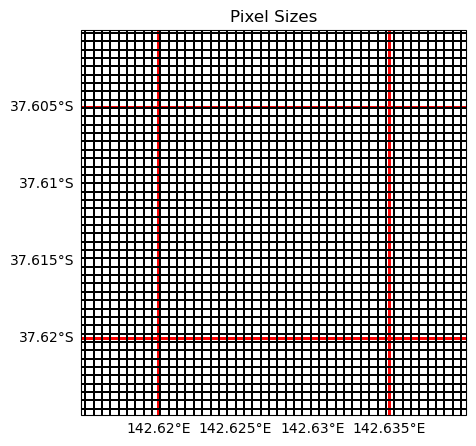

In [76]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
prefire_oci_ds["reflectance"].sel({"wavelengths":860}, method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", transform=ccrs.PlateCarree(),linewidth=2, edgecolors="red", add_colorbar=False)
prefire_emit_ds["reflectance"].sel({"wavelengths":860}, method="nearest").plot(vmin=0, vmax=1, cmap="viridis", transform=ccrs.PlateCarree(),  linewidth=0.05, edgecolors="k", add_colorbar=False, alpha=1)
ax.set_extent([142.615, 142.64, -37.625, -37.60])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Sizes")
plt.show()

We can see that in addition to the discrepancy in size, the EMIT and PACE grids are not spatially aligned. This misalignment poses the same issue as when we were talking about intra-sensor comparisons, with the added complexity of the pixel size differences. We can use the `grid_data` function to regrid and resample either dataset, coarsening EMIT to match PACE's resolution, or sharpening (interpolating) PACE onto EMIT's finer grid. 

<div class="alert alert-warning" role="alert">

It is important to note that sharpening the data does not increase the information content of the data.

</div>

In other words, this approach will be duplicating existing values to fill a larger quantity of pixels covering the same spatial extent, which is still useful to compare PACE spectra at EMIT locations. This will also enable us to do band math, etc. 

In [78]:
oci_finer = pace.grid_data(src=prefire_oci_ds, 
                           dst_transform=prefire_emit_ds.rio.transform())

now plot to see pixel alignment

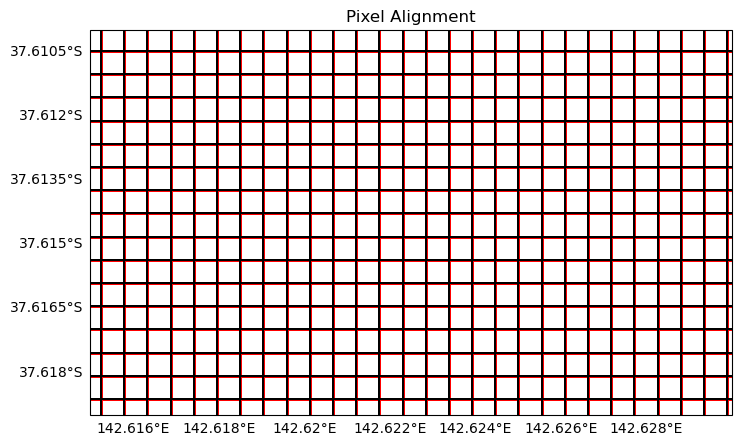

In [86]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
oci_finer["reflectance"].sel({"wavelengths":860}, 
                   method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", 
                                          transform=ccrs.PlateCarree(), 
                                          linewidth=2, edgecolors="red", 
                                          add_colorbar=False)
prefire_emit_ds["reflectance"].sel({"wavelengths":860}, 
                             method="nearest").plot(vmin=0, vmax=1, 
                                                    transform=ccrs.PlateCarree(),  
                                                    linewidth=0.05, edgecolors="k", 
                                                    add_colorbar=False)

ax.set_extent([142.615, 142.63, -37.619, -37.61])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Alignment")
plt.show()

We can see the pixels are aligned, which would allow for spectral comparisons between the two datasets. A similar method could be used to coarsen the EMIT data to PACE's resolution. 

now see how fire evolves with pace over time, taking the yarram fire as an example to see how the median spectrum changed in this area over time. 

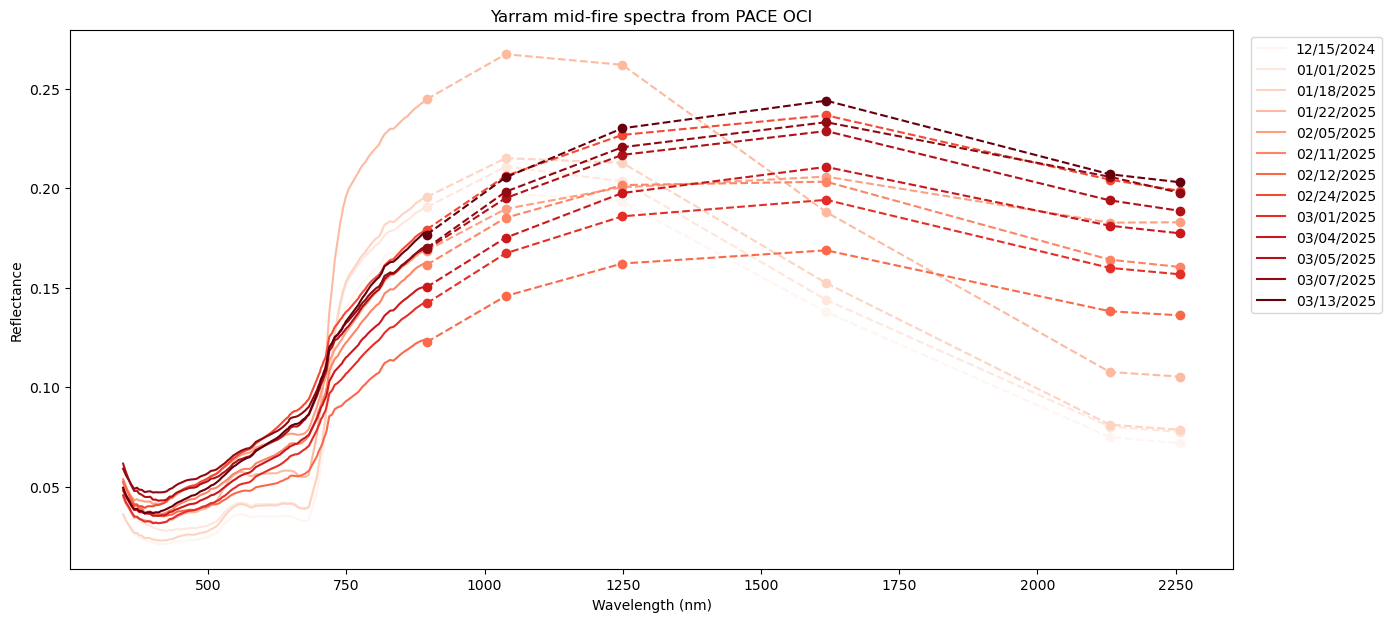

In [ ]:
# NOTE: Could make this another hover plot if we want? but simpler to do static for now
cmap = plt.get_cmap("Reds")
rgbs = cmap(np.linspace(0, 1, len(pace_ts_subsets)))

fig, ax = plt.subplots(figsize=(15,7))
for i in range(len(pace_ts_subsets)):
    ts=pace_ts_subsets[i].name[9:17]
    ds = xr.open_dataset(pace_ts_subsets[i])

    # Sel sections to compute the median on for the yarram fire
    ds_yarram = ds["rhos"].sel({"longitude":slice(142.2, 142.3), 
                                "latitude":slice(-37.28, -37.4)}).median(dim=["latitude", "longitude"])
    
    ax.plot(ds["wavelength_3d"][:-6], ds_yarram[:-6], c=rgbs[i], label=f"{ts[4:6]}/{ts[6:]}/{ts[:4]}")
    ax.plot(ds["wavelength_3d"][-6:], ds_yarram[-6:], c=rgbs[i], ls='--', marker='o')
ax.set_title("Yarram mid-fire spectra from PACE OCI")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()
    

Can see the burnt material and spectral shape change over the course of the fire (which started ~ Dec 21st). Change in spectral shape due to broken down cell structure etc., this is why NBR (next notebook?) works.

<div class="alert alert-info" role="alert">

You have completed the second notebook in the PACE+EMIT series. We suggest moving on to the third notebook, `03_NBR_with_PACE_EMIT`, which uses the data we aligned here to conduct a burn analysis on wildfires which occurred in Grampians National Park, Victoria, Australia in 2024-2025.

</div>